# Analisys of Experiments

**Overview**
Analysis of the experimental date for window and low threshold selection

1. Identify the best window size for sensitivity
2. Identify the best low threshold producing most discriminating features

## Imports & Config

In [1]:
import sys
from itertools import combinations
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
from scipy.stats import beta

# matplotlib.use("Agg")

sys.path.append(str(Path.cwd().parent))
from utils import UF
from df_wrapper import CandidateFrame

plt.rcParams.update(
    {
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

GRAPHICS_DIR = Path("../Graphics")
CSV = "../Data/experiments/combined_candidates.csv"
COORDS = ["centroid_z", "centroid_y", "centroid_x"]
PEAKS = ["peak_z", "peak_y", "peak_x"]
TOL = 2.0  # Matching tolerance for particle coordinates (in pixels)

# radial bands reflecting jellyroll geometry (core/tab -> periphery)
RBANDS = [
    (0, 105, "core/tab <105"),
    (105, 150, "inner 105-150"),
    (150, 300, "inner 150-300"),
    (300, 450, "mid 300-450"),
    (450, 600, "outer 450-600"),
    (600, 10_000, "edge >=600"),
]

feature_analysis_exclude_cells_with_added_particles = True
feature_analysis_exclude_radial_pos = False
candidate_frame = CandidateFrame(CSV)
df_raw = candidate_frame.df# .read_csv(CSV)  # NO radial filter (it was removing true positives)
WINDOWS = sorted(df_raw.slab_thickness.unique())




def build_matrix(mask_df, cols=COORDS):
    """
    Returns: (detection matrix [n_obj x n_win], size array, radial array) for
    the labeled candidates in mask_df, deduped into unique physical objects.
    size   = max n_voxels across the object's detections
    radial = mean radial_pos across the object's detections (location is stable)

    Interpret the matrix as a binary indicator (r,c): the r-th unique particle was
    identified in the c-th window. The number of rows is the number of unique physical
    objects and the columns index the window-sizes.
    """
    rows, sizes, radial = [], [], []
    for _, g in mask_df.groupby("volume_name", sort=False):
        g = g.reset_index(drop=True)
        if len(g) == 0:
            continue
        pts = g[cols].values
        uf = UF(len(g))
        for a, b in cKDTree(pts).query_pairs(TOL):
            uf.union(a, b)
        cl = {}
        for i in range(len(g)):
            cl.setdefault(uf.find(i), []).append(i)
        wv = g.slab_thickness.values
        nv = g.n_voxels.values
        rv = g.radial_pos.values
        for members in cl.values():
            ws = set(wv[members].tolist())
            rows.append([1 if w in ws else 0 for w in WINDOWS])
            sizes.append(nv[members].max())
            radial.append(rv[members].mean())
    return np.array(rows), np.array(sizes), np.array(radial)

# ---- exact CI helpers (unified) --------------------------------------------
def clopper_pearson(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    """Exact (Clopper-Pearson) 1-alpha CI for a binomial proportion k / n."""
    if n == 0:
        return (0.0, 1.0)
    lo = 0.0 if k == 0 else beta.ppf(alpha / 2, k, n - k + 1)
    hi = 1.0 if k == n else beta.ppf(1 - alpha / 2, k + 1, n - k)
    return (float(lo), float(hi))


def paired_diff_ci(
    b: int, c: int, n: int, alpha: float = 0.05
) -> tuple[float, float, float]:
    """Exact-conditional CI for p_A - p_B in PAIRED binary data.

    b = # items where A succeeds and B fails   (A-only)
    c = # items where B succeeds and A fails    (B-only)
    n = total paired items.
    Returns (point_diff, lo, hi) for (p_A - p_B) = (b - c) / n.
    Dual to the exact McNemar test: (lo, hi) excludes 0  <=>  test rejects.
    """
    n_disc = b + c
    d = (b - c) / n
    if n_disc == 0:
        return (0.0, 0.0, 0.0)
    pi_lo, pi_hi = clopper_pearson(b, n_disc, alpha)  # pi = P(A-only | discordant)
    lo = n_disc * (2 * pi_lo - 1) / n
    hi = n_disc * (2 * pi_hi - 1) / n
    return (float(d), float(lo), float(hi))


def proportion_cis(counts: dict[str, int], n: int, family_alpha: float = 0.05):
    """Per-group proportion CIs: nominal (each 1-family_alpha) and Bonferroni
    (each 1 - family_alpha / n_groups) for simultaneous coverage."""
    g = len(counts)
    out = {}
    for name, k in counts.items():
        out[name] = {
            "p": k / n,
            "nominal": clopper_pearson(k, n, family_alpha),
            "bonferroni": clopper_pearson(k, n, family_alpha / g),
        }
    return out


def pairwise_diff_cis(M: np.ndarray, labels: list, family_alpha: float = 0.05):
    """M: (n_items x n_groups) binary success matrix (paired across columns).
    Returns list of dicts with per-pair diff, discordant counts, nominal &
    Bonferroni CIs, and whether the Bonferroni CI excludes 0."""
    n, g = M.shape
    m = g * (g - 1) // 2  # number of comparisons
    rows = []
    for i, j in combinations(range(g), 2):
        b = int(((M[:, i] == 1) & (M[:, j] == 0)).sum())
        c = int(((M[:, i] == 0) & (M[:, j] == 1)).sum())
        d, l1, h1 = paired_diff_ci(b, c, n, family_alpha)
        _, l2, h2 = paired_diff_ci(b, c, n, family_alpha / m)
        rows.append(
            {
                "A": labels[i],
                "B": labels[j],
                "A_only": b,
                "B_only": c,
                "diff": d,
                "nominal": (l1, h1),
                "bonferroni": (l2, h2),
                "bonf_excludes_0": (l2 > 0 or h2 < 0),
            }
        )
    return rows
# ----------------------------------------------------------------------------

# High Level Breakbown of Experimental Data with Labels

## Data in Aggregate

In [50]:
TOL = np.sqrt(0.75)
particles_frame = candidate_frame.filter_on_column_values("particle", [1, 2, 3])
#particles_frame = particles_frame.filter_on_column_values("low_threshold_scale", 2.75)
res_centroids = particles_frame.label_unique(
    measure_cols=["centroid_z", "centroid_y", "centroid_x"], tol=TOL
)
res_peaks = particles_frame.label_unique(
    measure_cols=["peak_z", "peak_y", "peak_x"], tol=TOL
)

print("Centroids:")
n_unique_particles = len(res_centroids[11])
print("Total number of unique particles:", n_unique_particles)
for k, v in res_centroids.items():
    n_found = v.sum()
    print(f"Partition {k}: {n_found} ({n_found / n_unique_particles:.3f})")
print()


print("Peaks:")
n_unique_particles = len(res_peaks[11])
print("Total number of unique particles:", n_unique_particles)
for k, v in res_peaks.items():
    n_found = v.sum()
    print(f"Partition {k}: {n_found} ({n_found / n_unique_particles:.3f})")


Centroids:
Total number of unique particles: 622
Partition 11: 506 (0.814)
Partition 15: 543 (0.873)
Partition 21: 559 (0.899)
Partition 23: 566 (0.910)
Partition 25: 542 (0.871)
Partition 31: 529 (0.850)

Peaks:
Total number of unique particles: 834
Partition 11: 507 (0.608)
Partition 15: 542 (0.650)
Partition 21: 559 (0.670)
Partition 23: 564 (0.676)
Partition 25: 541 (0.649)
Partition 31: 527 (0.632)


## After Partitioning into Lower Threshold Vals

In [51]:
unique_windows = sorted(candidate_frame.df["slab_thickness"].unique())
unique_LT = sorted(candidate_frame.df["low_threshold_scale"].unique())

res_lower_theshold = {}
for ult in unique_LT:
    pf = particles_frame.filter_on_column_values("low_threshold_scale", ult)

    res_w = {}
    unique_labels = pf.label_unique(partition_column = 'slab_thickness',
                                              measure_cols=["peak_z", "peak_y", "peak_x"],
                                              tol=TOL)
    res_lower_theshold[ult] = unique_labels




In [49]:
for rlt, vdict in res_lower_theshold.items():
    n_unique_particles = vdict[23].shape[0]
    print(f"Low threshold scale: {rlt}, unique particles: {n_unique_particles}")
    for slab_thickness, labels in vdict.items():
        print(f"  Slab thickness: {slab_thickness}, found: {labels.sum()}, fraction: {labels.sum() / n_unique_particles:.3f}")


Low threshold scale: 2.5, unique particles: 692
  Slab thickness: 11, found: 498, fraction: 0.720
  Slab thickness: 15, found: 529, fraction: 0.764
  Slab thickness: 21, found: 535, fraction: 0.773
  Slab thickness: 23, found: 528, fraction: 0.763
  Slab thickness: 25, found: 515, fraction: 0.744
  Slab thickness: 31, found: 502, fraction: 0.725
Low threshold scale: 2.75, unique particles: 693
  Slab thickness: 11, found: 500, fraction: 0.722
  Slab thickness: 15, found: 533, fraction: 0.769
  Slab thickness: 21, found: 541, fraction: 0.781
  Slab thickness: 23, found: 537, fraction: 0.775
  Slab thickness: 25, found: 524, fraction: 0.756
  Slab thickness: 31, found: 510, fraction: 0.736
Low threshold scale: 3.0, unique particles: 691
  Slab thickness: 11, found: 502, fraction: 0.726
  Slab thickness: 15, found: 535, fraction: 0.774
  Slab thickness: 21, found: 546, fraction: 0.790
  Slab thickness: 23, found: 537, fraction: 0.777
  Slab thickness: 25, found: 531, fraction: 0.768
  Sla

In [46]:
df = df_raw[df_raw['particle'].isin([1,2,3])]
print(len(df))

m = build_matrix(df)[0]

10511


In [48]:
m.shape
for n in range(m.shape[1]):
    print(m[:, n].sum())

506
541
559
561
541
528


# High Level Overview

## Compute Total Candidates and Those Reviewed

In [17]:
total_candidates = len(df_raw)
total_reviewed = len(df_raw[df_raw['particle'].isin([0, 1, 2, 3, 4])])

print("Total candidates:", total_candidates)
print("Total reviewed:", total_reviewed)
print("Fraction reviewed:", round(total_reviewed / total_candidates,3) if total_candidates > 0 else 0)

Total candidates: 502618
Total reviewed: 32319
Fraction reviewed: 0.064


## Recall vs Window Size
One caveat to keep in mind is: has the labeling been uniformly applied to all of the winddow sizes? That is, there might be a labeling bias.

In [18]:

# unique-object matrices: particles (TP) and non-particles (FP)
matching_cols = COORDS
TOL = 2.0
M_TP, size_TP, radial_pos_TP = build_matrix(df_raw[df_raw.particle.isin([1, 2, 3])], cols=matching_cols)  # TP
M_FP, size_FP, radial_pos_FP = build_matrix(df_raw[df_raw.particle == 0], cols=matching_cols)  # labeled non-particle
labels = [str(w) for w in WINDOWS]

n_unique_particles = len(M_TP)
n_unique_non_particles = len(M_FP)
print("Number of unique particles:", n_unique_particles, "\nNumber of unique non-particles:", n_unique_non_particles)

TPs_per_window = [np.sum(M_TP[:, i]) for i in range(M_TP.shape[1])]
FPs_per_window = [np.sum(M_FP[:, i]) for i in range(M_FP.shape[1])]

# reviewed = manually labeled candidates (particle in [1,2,3,4]), deduped into unique
# physical objects the same way as TP/FP so it lines up with the same WINDOWS order
M_reviewed, size_reviewed, radial_pos_reviewed = build_matrix(
    df_raw[df_raw.particle.isin([0, 1, 2, 3, 4])], cols=matching_cols
)
reviewed_per_window = [np.sum(M_reviewed[:, i]) for i in range(M_reviewed.shape[1])]

for w, tp, fp, reviewed in zip(labels, TPs_per_window, FPs_per_window, reviewed_per_window):
    print(f"W {w}: {tp} TP, FP {fp}, classified: {tp + fp}, reviewed: {reviewed} recall {tp / n_unique_particles:.3f}")


Number of unique particles: 611 
Number of unique non-particles: 1824
W 11: 506 TP, FP 933, classified: 1439, reviewed: 1821 recall 0.828
W 15: 540 TP, FP 784, classified: 1324, reviewed: 1705 recall 0.884
W 21: 558 TP, FP 841, classified: 1399, reviewed: 1752 recall 0.913
W 23: 560 TP, FP 931, classified: 1491, reviewed: 1834 recall 0.917
W 25: 540 TP, FP 836, classified: 1376, reviewed: 1706 recall 0.884
W 31: 528 TP, FP 883, classified: 1411, reviewed: 1710 recall 0.864


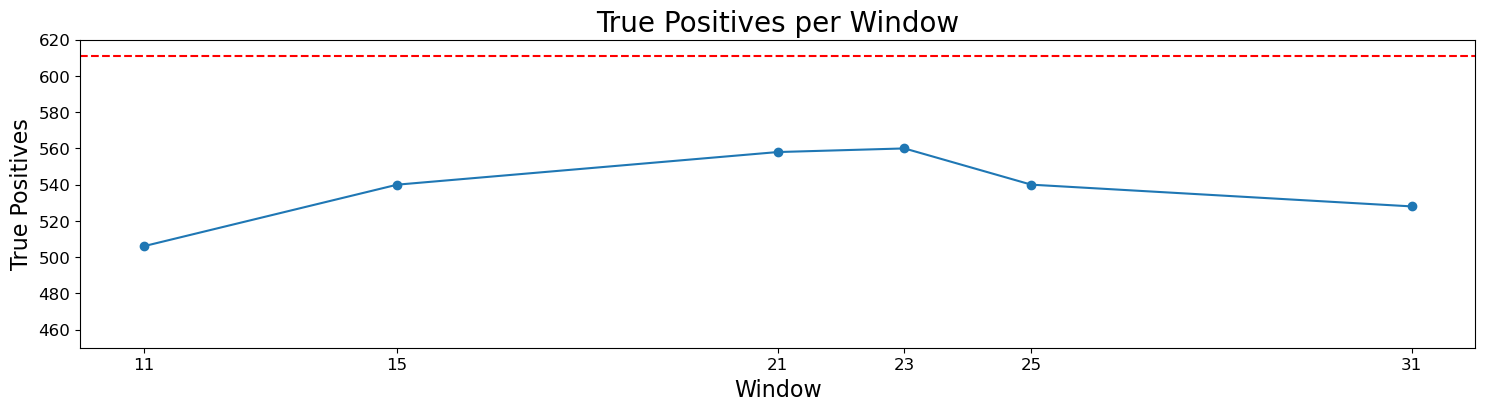

In [29]:
plt.figure(figsize=(18, 4))
plt.plot(WINDOWS, TPs_per_window, marker='o')
plt.xlabel("Window")
plt.ylabel("True Positives")
plt.title("True Positives per Window")
plt.xticks(WINDOWS)
plt.axhline(y=n_unique_particles, color='r', linestyle='--')
plt.ylim(450, 620)
plt.show()

# Window Size Selection
Inspect the detection rate per window size to determine best window size

In [ ]:
"""Size-stratified window recall: does dropping narrow windows matter more for
LARGE particles? Restrict the unique-particle set to max-extent >= {20, 30}
voxels and rerun per-window recall CIs + Bonferroni pairwise-difference CIs.

Self-contained: exact-conditional CI helpers are inlined (no local imports).
"""
df = df_raw.copy()  # NO radial filter (it was removing true positives)

# unique-object matrices: particles (TP) and non-particles (FP)
M_all, S, R = M_TP, size_TP, radial_pos_TP
M_non, S_non, R_non = M_FP, size_FP, radial_pos_FP  # labeled non-particle

agg_particle_info: dict[str, dict] = {}


def run(thr, title):
    M = M_all[S >= thr]
    N = len(M)
    Mn = M_non[S_non >= thr]
    Nn = len(Mn)
    print("\n" + "=" * 66)
    print(f"{title}   (TP N = {N},  non-particle N = {Nn})")
    print("=" * 66)
    counts = {str(w): int(M[:, j].sum()) for j, w in enumerate(WINDOWS)}
    ncounts = {str(w): int(Mn[:, j].sum()) for j, w in enumerate(WINDOWS)}
    print(
        "Per-window:  TP recall (nominal | Bonf 95%)          | non-particles (FP) detected"
    )

    # region Aggregate information for later plotting
    global agg_particle_info
    agg_dict = {}
    agg_dict["TP_N"] = N
    agg_dict["FP_N"] = Nn
    agg_particle_info[title] = agg_dict
    # endregion

    for j, w in enumerate(WINDOWS):
        r = proportion_cis(counts, N)[str(w)]
        fp = ncounts[str(w)]
        fp_ratio = fp / max(counts[str(w)], 1)
        print(
            f"  win {w:>2d}: {r['p']:6.1%} ({counts[str(w)]:3d})  "
            f"nominal [{r['nominal'][0]:.1%}, {r['nominal'][1]:.1%}]  "
            f"Bonf [{r['bonferroni'][0]:.1%}, {r['bonferroni'][1]:.1%}]"
            f"  |  FP={fp:3d}  (FP/TP={fp_ratio:.2f})"
        )
        agg_dict[int(w)] = {
            "TP_count": counts[str(w)],
            "FP_count": ncounts[str(w)],
            "TP_recall_nominal": r["nominal"],
            "TP_recall_bonferroni": r["bonferroni"],
        }
    print("Bonferroni pairwise TP-recall differences that EXCLUDE 0 (else 'none'):")
    any_sig = False
    for r in pairwise_diff_cis(M, labels):
        if r["bonf_excludes_0"]:
            any_sig = True
            print(
                f"  {r['A']:>2s}-{r['B']:>2s}: {r['diff']:+6.1%}  "
                f"Bonf [{r['bonferroni'][0]:+.1%}, {r['bonferroni'][1]:+.1%}]  "
                f"(A_only={r['A_only']}, B_only={r['B_only']})"
            )
    if not any_sig:
        print("  none")

    # radial map: where do the (unique) FPs and TPs sit?
    r_tp = R[S >= thr]
    r_fp = R_non[S_non >= thr]
    print("Radial breakdown of unique objects (TP vs FP):")
    print(f"  {'band':16s} {'TP':>5s} {'FP':>5s} {'FP%ofband':>10s} {'%allFP':>7s}")
    for lo, hi, name in RBANDS:
        ntp = int(((r_tp >= lo) & (r_tp < hi)).sum())
        nfp = int(((r_fp >= lo) & (r_fp < hi)).sum())
        frac_band = nfp / max(ntp + nfp, 1)
        frac_fp = nfp / max(len(r_fp), 1)
        print(f"  {name:16s} {ntp:5d} {nfp:5d} {frac_band:9.0%} {frac_fp:7.0%}")
    return r_tp, r_fp


In [ ]:
strata = [
    (0, "ALL particles"),
    (20, "max extent >= 20 voxels"),
    (30, "max extent >= 30 voxels"),
]
results = {thr: run(thr, title) for thr, title in strata}

# ---- radial-map figure: FP vs TP radial distribution per size stratum ----
fig, axes = plt.subplots(1, len(strata), figsize=(18, 5), sharex=True)
bins = np.linspace(0, max(R.max(), R_non.max()), 40)
for ax, (thr, title) in zip(axes, strata):
    r_tp, r_fp = results[thr]
    ax.hist(r_fp, bins=bins, alpha=0.55, color="tab:gray", label=f"FP (n={len(r_fp)})")
    ax.hist(r_tp, bins=bins, alpha=0.55, color="tab:red", label=f"TP (n={len(r_tp)})")
    for lo, _, _ in RBANDS[1:]:
        ax.axvline(lo, color="k", ls=":", lw=0.6)
    ax.set_title(title)
    ax.set_xlabel("radial_pos")
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel("unique-object count")
plt.suptitle("Radial map: false positives vs true particles, by size stratum")
plt.tight_layout()
plt.savefig(f"{GRAPHICS_DIR / 'fp_radial_map.png'}", dpi=120)
plt.show()
print("\nsaved fp_radial_map.png")

In [ ]:
total_TPs = agg_particle_info["ALL particles"]["TP_N"]
total_FPs = agg_particle_info["ALL particles"]["FP_N"]
print(f"\nTotal unique TPs for all particles: {total_TPs}")
print(f"Total unique FPs for all particles: {total_FPs}")

In [ ]:
title = ["all", "20", "30"]
total_TPs = {}
total_FPs = {}
for n, (key, value) in enumerate(agg_particle_info.items()):
    total_TPs[title[n]] = value["TP_N"]
    total_FPs[title[n]] = value["FP_N"]

particle_info = {}
for s in strata:
    particle_info[s[0]] = agg_particle_info[s[1]]

print(f"\nTotal unique TPs for all particles: {total_TPs}")
print(f"Total unique FPs for all particles: {total_FPs}")

In [ ]:
p_titles = [
    "Particles Detected Per Window",
    "Large Particles (>=20) Detected Per Window",
    "Large Particles (>=30) Detected per Window",
]

np_titles = [
    "Non-Particles Detected Per Window",
    "Large Non-Particles (>=20) Detected Per Window",
    "Large Non-Particles (>=30) Detected per Window",
]

which_strata = 1
pi = particle_info[strata[which_strata][0]]
w = [i for i in pi.keys() if i not in ["TP_N", "FP_N"]]

num_particles = pi["TP_N"]
num_non_particles = pi["FP_N"]
particles_per_window = [pi[_w]["TP_count"] for _w in w]
non_particles_per_window = [pi[_w]["FP_count"] for _w in w]

print(f"Number of particles: {num_particles}")
print(f"Number of non-particles: {num_non_particles}")

plt.figure(figsize=(18, 8))
plt.plot(w, particles_per_window, label="Particles Detected", marker="o")
plt.xlabel("Window Size")
plt.ylabel("Count")
plt.title(p_titles[which_strata])
plt.xticks(w)
plt.legend()
plt.show()

plt.figure(figsize=(18, 8))
plt.plot(w, non_particles_per_window, label="Non-Particles Detected", marker="o")
plt.xlabel("Window Size")
plt.ylabel("Count")
plt.title(np_titles[which_strata])
plt.xticks(w)
plt.legend()
plt.show()


# Low Threshold Selection
Inspect the predictive power of features for the low threshold to identify the best lower threshold

# Testing - Low Threshold

In [ ]:
"""k_low decision analysis at window 23  (reproducible evidence).

The choice of k_low is NOT a classification-accuracy optimisation: accuracy is
flat across k_low once a full feature set is used. It is a CONSTRAINED choice:

  go as HIGH as possible in k_low  -- higher k_low gives tighter, more compact
      regions (sphericity peak), suppresses merging, and stays on the accuracy
      plateau --  but STOP before the grow step truncates, because truncation
      destroys physical sizing and degrades the shape features.

This script computes, per k_low, every criterion that bears on that decision,
using ALL physically-meaningful features (no hand-picked subset), so the
argument is fully reproducible.

Criteria:
  A. Multivariate classification separability  (logistic + gbtree, GroupKFold by volume)
  B. Univariate separability of the top features (esp. sphericity, the #1 feature)
  C. Capture / truncation of TP regions (grow ratio, % near-seed, % truncated)
  D. Merging of TP regions (% n_seed_regions > 1)
  E. FP fragmentation (# labelled non-particle candidates)
"""
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# import matplotlib
# matplotlib.use("Agg")

CSV = "../Data/experiments/combined_candidates_23.csv"
df = pd.read_csv(CSV)
KLOWS = sorted(df.low_threshold_scale.unique())

feature_analysis_exclude_cells_with_added_particles = False
feature_analysis_exclude_radial_pos = False

if feature_analysis_exclude_cells_with_added_particles:
    df = df[
        ~df["volume_name"].isin(
            [
                "M50L-23",
                "M50L-22",
                "M50L-21",
                "M50L-20",
                "M50L-19",
                "M50L-18",
                "M50L-17",
                "M50L-16",
            ]
        )
    ]

# ---- FULL feature set: every numeric column that is a measured feature -------
# (exclude identifiers, run parameters, and absolute spatial position)
NON_FEATURES = {
    "volume_name",
    "particle",
    "exp_index",
    "experiment_number",
    "slab_thickness",
    "high_threshold_scale",
    "low_threshold_scale",
    "baseline_method",
    "z_extent_max",
    "vol_threshold",
    "aniso_factor",
    "small_vol_cutoff",
    "z_pad",
    "small_z_bounds",
    "metal_threshold",
    "z_min",
    "z_max",
    "centroid_z",
    "centroid_y",
    "centroid_x",
    "peak_x",
    "peak_y",
    "peak_z",
}
if feature_analysis_exclude_radial_pos:
    NON_FEATURES.add("radial_pos")

FEATS = [
    c
    for c in df.columns
    if c not in NON_FEATURES and pd.api.types.is_numeric_dtype(df[c])
]
TRUNC_NEAR = 1.5  # region < 1.5x seed  => grow step barely captured extent
TRUNC_HARD = 1.2  # region < 1.2x seed  => effectively seed-only


def auc(a, b):
    a, b = a.dropna(), b.dropna()
    if len(a) < 5 or len(b) < 5:
        return np.nan
    u = mannwhitneyu(a, b, alternative="two-sided").statistic
    return max(u / (len(a) * len(b)), 1 - u / (len(a) * len(b)))


def cv_auc(cell):
    """GroupKFold-by-volume CV AUC for logistic and gradient-boosted trees."""
    c = cell[cell.particle.isin([0, 1, 2, 3])].copy()
    c["y"] = c.particle.isin([1, 2, 3]).astype(int)
    X = c[FEATS].replace([np.inf, -np.inf], np.nan).fillna(0).values
    y = c.y.values
    g = c.volume_name.values
    lr_s, gb_s = [], []
    for tr, te in GroupKFold(5).split(X, y, g):
        if len(np.unique(y[te])) < 2:
            continue
        sc = StandardScaler().fit(X[tr])
        lr = LogisticRegression(max_iter=2000).fit(sc.transform(X[tr]), y[tr])
        lr_s.append(roc_auc_score(y[te], lr.predict_proba(sc.transform(X[te]))[:, 1]))
        gb = HistGradientBoostingClassifier(max_iter=200, max_depth=3).fit(X[tr], y[tr])
        gb_s.append(roc_auc_score(y[te], gb.predict_proba(X[te])[:, 1]))
    return np.mean(lr_s), np.std(lr_s), np.mean(gb_s), np.std(gb_s)


## Report

In [ ]:
print(f"Feature set: {len(FEATS)} features")
print(FEATS)

# top features by univariate AUC at k_low=3.0 (reference point)
c30 = df[df.low_threshold_scale == 3.0]
rank = sorted(
    (
        (auc(c30[c30.particle.isin([1, 2, 3])][f], c30[c30.particle == 0][f]), f)
        for f in FEATS
    ),
    reverse=True,
)
top_feats = [f for _, f in rank[:6]]
print(
    "\nTop-6 univariate features @k_low=3.0:", [(round(a, 3), f) for a, f in rank[:6]], "\n"
)

# ---- assemble per-k_low criteria table --------------------------------------
rows = []
for k in KLOWS:
    c = df[df.low_threshold_scale == k]
    tp = c[c.particle.isin([1, 2, 3])]
    nn = c[c.particle == 0]
    gr = tp.n_voxels / tp.n_seed_total.clip(lower=1)
    lr_m, lr_s, gb_m, gb_s = cv_auc(c)
    row = {
        "k_low": k,
        "cv_logistic": lr_m,
        "cv_logistic_std": lr_s,
        "cv_gbtree": gb_m,
        "cv_gbtree_std": gb_s,
        "sphericity_auc": auc(tp["sphericity"], nn["sphericity"]),
        "grow_median": gr.median(),
        "pct_near_seed": (gr < TRUNC_NEAR).mean() * 100,
        "pct_truncated": (gr < TRUNC_HARD).mean() * 100,
        "merge_pct": (tp.n_seed_regions > 1).mean() * 100,
        "n_fp": len(nn),
    }
    for f in top_feats:
        row[f"auc_{f}"] = auc(tp[f], nn[f])
    rows.append(row)
T = pd.DataFrame(rows).set_index("k_low")

pd.set_option("display.width", 200, "display.max_columns", 30)
print("\n================ per-k_low decision table ================")
print(
    T[
        [
            "cv_logistic",
            "cv_logistic_std",
            "cv_gbtree",
            "cv_gbtree_std",
            "sphericity_auc",
            "grow_median",
            "pct_near_seed",
            "pct_truncated",
            "merge_pct",
            "n_fp",
        ]
    ].round(3)
)


# ---- decision rule as a function (so thresholds can be swept) ----------------
def pick_klow(T, plateau_tol, trunc_ceiling):
    """Feasible = on accuracy plateau AND truncation-acceptable; pick the
    highest feasible k_low (max compactness/least merging w/o over-truncating)."""
    best = T.cv_logistic.max()
    plateau = set(T.index[T.cv_logistic >= best - plateau_tol])
    usable = set(T.index[T.pct_near_seed <= trunc_ceiling])
    feasible = sorted(plateau & usable)
    return (max(feasible) if feasible else None), feasible


# ---- the argument at the nominal thresholds ----------------------------------
print("\n================ decision logic (nominal thresholds) ================")
best_lr = T.cv_logistic.max()
PLATEAU_TOL, TRUNC_CEIL = 0.005, 15.0
pick, feasible = pick_klow(T, PLATEAU_TOL, TRUNC_CEIL)
print(
    f"A. Classification plateau (logistic within {PLATEAU_TOL} of best={best_lr:.3f}): "
    f"{sorted(set(T.index[T.cv_logistic >= best_lr - PLATEAU_TOL]))}"
)
print(
    f"C. Truncation-acceptable (<= {TRUNC_CEIL:.0f}% near-seed): "
    f"{sorted(set(T.index[T.pct_near_seed <= TRUNC_CEIL]))}"
)
print(f"   Feasible band: {feasible}")
print(f"B. Sphericity (#1 feature) peaks at k_low = {T.sphericity_auc.idxmax()}")
print(f"\n=> pick = highest feasible k_low = {pick}")

# ---- sensitivity sweep over the two thresholds -------------------------------
print(
    "\n================ sensitivity sweep (pick as fn of thresholds) ================"
)
TOLS = [0.003, 0.005, 0.010, 0.015, 0.020]  # accuracy plateau tolerance
CEILS = [8, 10, 11, 12, 15, 18, 20, 25, 30]  # % near-seed truncation ceiling
sweep = pd.DataFrame(index=TOLS, columns=CEILS, dtype=float)
for tol in TOLS:
    for ceil in CEILS:
        p, _ = pick_klow(T, tol, ceil)
        sweep.loc[tol, ceil] = p
sweep.index.name = "plateau_tol \\ trunc_ceiling(%)"
print(sweep.to_string())
picks, freq = np.unique(sweep.values[~pd.isna(sweep.values)], return_counts=True)
print("\npick frequency across the sweep grid:")
for p, f in sorted(zip(picks, freq), key=lambda x: -x[1]):
    print(
        f"  k_low={p}: chosen in {f}/{sweep.size} cells ({100 * f / sweep.size:.0f}%)"
    )
sweep.to_csv("../Graphics/klow_sensitivity_sweep.csv")
print("saved klow_sensitivity_sweep.csv")


## Figures

### Multivariate Classification

In [ ]:
T.cv_logistic_std


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(18, 5))
ax.errorbar(
    KLOWS,
    T.cv_logistic,
    yerr=T.cv_logistic_std,
    marker="o",
    label="logistic",
    capsize=7,
    alpha=0.5,
)
ax.errorbar(
    KLOWS,
    T.cv_gbtree,
    yerr=T.cv_gbtree_std,
    marker="s",
    label="gbtree",
    capsize=7,
    alpha=0.5,
)
ax.axhline(
    best_lr - 0.0074, color="gray", ls=":", lw=1, label="plateau band (logistic)"
)
ax.set_title("Multivariate Classification AUC - Leave-One-Out Cross Validation")
ax.set_xlabel("Low Threshold")
ax.set_ylabel("CV AUC")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(KLOWS)
plt.show()

### Strongest Features

In [ ]:
# Sphericity
sph_peak = T.sphericity_auc.idxmax()
rp_peak = T.auc_radial_pos.idxmax()

fig, ax = plt.subplots(1, 1, figsize=(18, 5))
ax.plot(
    KLOWS,
    T.sphericity_auc,
    marker="o",
    color="tab:purple",
    label="Sphericity",
)
ax.plot(
    KLOWS,
    T.auc_radial_pos,
    marker="o",
    color="tab:blue",
    label="Radial Position",
)
ax.plot(
    KLOWS,
    T.auc_n_seed,
    marker="o",
    color="tab:green",
    label="N Seed",
)
ax.plot(
    KLOWS,
    T.auc_snr_cluster,
    marker="o",
    color="tab:red",
    label="SNR Cluster",
)
ax.plot(
    KLOWS,
    T.auc_n_voxels,
    marker="o",
    color="tab:orange",
    label="N Voxels",
)
ax.plot(
    KLOWS,
    T.auc_n_seed_total,
    marker="o",
    color="tab:brown",
    label="N Seed Total",
)
ax.axvline(rp_peak, color="tab:blue", ls=":", lw=1)
ax.set_xlabel("k_low")
ax.set_ylabel("AUC")
ax.tick_params(axis="y")
ax.tick_params(axis="x")
plt.xticks(KLOWS)
ax.axvline(sph_peak, color="tab:purple", ls=":", lw=1)
ax.set_title("AUC of Top-Feature Separability")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.ylim(0.7, 0.9)


In [ ]:
T.columns

### ????

In [ ]:
ax[2].plot(
    KLOWS, T.pct_near_seed, marker="s", color="tab:red", label="% TP near-seed (<1.5x)"
)
ax[2].plot(KLOWS, T.merge_pct, marker="^", color="tab:green", label="% TP merged")
ax[2].axhline(15, color="gray", ls=":", lw=1, label="truncation ceiling (15%)")
if pick is not None:
    ax[2].axvline(pick, color="k", ls="--", lw=1.2, label=f"pick={pick}")
ax[2].set_title("C. Truncation vs merging (the constraint)")
ax[2].set_xlabel("k_low")
ax[2].set_ylabel("% of TPs")
ax[2].legend()
ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graphics/klow_decision.png", dpi=120)
print("\nsaved klow_decision.png")
T.round(4).to_csv("../Data/experiments/klow_decision_table.csv")
print("saved klow_decision_table.csv into the experiments folder")


## Sensitivity Sweep Heatmap

In [ ]:
# ---- sensitivity-sweep heatmap -----------------------------------------------
uniq = sorted(np.unique(sweep.values[~pd.isna(sweep.values)]))
cmap = {v: i for i, v in enumerate(uniq)}
grid = np.vectorize(lambda v: cmap.get(v, np.nan))(sweep.values.astype(float))
fig2, axh = plt.subplots(figsize=(9, 4))
im = axh.imshow(grid, aspect="auto", cmap="YlGnBu")
axh.set_xticks(range(len(CEILS)))
axh.set_xticklabels(CEILS)
axh.set_yticks(range(len(TOLS)))
axh.set_yticklabels(TOLS)
axh.set_xlabel("truncation ceiling (% TP near-seed)")
axh.set_ylabel("accuracy plateau tolerance")
axh.set_title("Selected k_low vs decision thresholds")
for i in range(len(TOLS)):
    for j in range(len(CEILS)):
        v = sweep.values[i, j]
        axh.text(
            j,
            i,
            "-" if pd.isna(v) else f"{v:g}",
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )
# discrete legend

axh.legend(
    handles=[
        Patch(facecolor=im.cmap(im.norm(cmap[v])), label=f"k_low={v:g}") for v in uniq
    ],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.savefig("../Graphics/klow_sensitivity_sweep.png", dpi=120)
print("saved klow_sensitivity_sweep.png into the Graphics folder")

## Increasing the folds to leave-one-out (23)

In [ ]:
"""Leave-one-volume-out (23 folds) re-run of the k_low classification comparison.

Purpose: the 5-fold paired test was underpowered (nothing significant, all p>0.3).
LOO gives 23 paired folds -> more power to detect whether 3.25/3.5 actually
differ from the best k_low on classification.

Each fold holds out ONE volume. AUC is undefined if the held-out volume lacks
either class, so we keep only volumes usable at EVERY k_low, and pair the
per-volume AUCs across k_low for a paired t-test.
"""
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_rel, wilcoxon

df = pd.read_csv("../Data/experiments/combined_candidates_23.csv")

feature_analysis_exclude_cells_with_added_particles = True
feature_analysis_exclude_radial_pos = False
if feature_analysis_exclude_cells_with_added_particles:
    df = df[
        ~df["volume_name"].isin(
            [
                "M50L-23",
                "M50L-22",
                "M50L-21",
                "M50L-20",
                "M50L-19",
                "M50L-18",
                "M50L-17",
                "M50L-16",
            ]
        )
    ]

NON = {
    "experiment_number",
    "volume_name",
    "particle",
    "exp_index",
    "slab_thickness",
    "high_threshold_scale",
    "low_threshold_scale",
    "baseline_method",
    "z_extent_max",
    "vol_threshold",
    "aniso_factor",
    "small_vol_cutoff",
    "z_pad",
    "small_z_bounds",
    "metal_threshold",
    "z_min",
    "z_max",
    "centroid_z",
    "centroid_y",
    "centroid_x",
    "peak_x",
    "peak_y",
    "peak_z",
}
if feature_analysis_exclude_radial_pos:
    NON.add("radial_pos")
FEATS = [c for c in df.columns if c not in NON and pd.api.types.is_numeric_dtype(df[c])]
KLOWS = sorted(df.low_threshold_scale.unique())


def loo_auc(k, model):
    """Return dict {volume: held-out AUC} for one k_low and model."""
    c = df[(df.low_threshold_scale == k) & (df.particle.isin([0, 1, 2, 3]))].copy()
    c["y"] = c.particle.isin([1, 2, 3]).astype(int)
    X = c[FEATS].replace([np.inf, -np.inf], np.nan).fillna(0).values
    y = c.y.values
    g = c.volume_name.values
    out = {}
    for tr, te in LeaveOneGroupOut().split(X, y, g):
        vol = g[te][0]
        if len(np.unique(y[te])) < 2:  # need both classes in held-out volume
            continue
        if model == "logistic":
            sc = StandardScaler().fit(X[tr])
            m = LogisticRegression(max_iter=2000).fit(sc.transform(X[tr]), y[tr])
            p = m.predict_proba(sc.transform(X[te]))[:, 1]
        else:
            m = HistGradientBoostingClassifier(max_iter=200, max_depth=3).fit(
                X[tr], y[tr]
            )
            p = m.predict_proba(X[te])[:, 1]
        out[vol] = roc_auc_score(y[te], p)
    return out


g_means = {}
g_stds = {}
for model in ["logistic", "gbtree"]:
    per = {k: loo_auc(k, model) for k in KLOWS}
    common = set.intersection(
        *[set(per[k]) for k in KLOWS]
    )  # volumes usable at all k_low
    common = sorted(common)
    A = pd.DataFrame({k: [per[k][v] for v in common] for k in KLOWS}, index=common)
    means = A.mean()
    se = A.std(ddof=1) / np.sqrt(len(common))
    g_means[model] = means
    g_stds[model] = se
    best = means.idxmax()
    print(
        f"\n================ {model}  (LOO, {len(common)} usable volumes) ================"
    )
    print(f"best k_low = {best}  (macro-mean AUC {means[best]:.3f})")
    print(
        f"{'k_low':>6} {'mean AUC':>9} {'SE':>7} {'Δ vs best':>10} {'paired t p':>11} {'wilcoxon p':>11}"
    )
    for k in KLOWS:
        d = A[best] - A[k]
        if k == best:
            pt = pw = 1.0
        else:
            pt = ttest_rel(A[best], A[k]).pvalue
            try:
                pw = wilcoxon(A[best], A[k]).pvalue
            except ValueError:
                pw = np.nan
        print(
            f"{k:6.2f} {means[k]:9.3f} {se[k]:7.4f} {d.mean():10.3f} {pt:11.3f} {pw:11.3f}"
        )

In [ ]:
which = "gbtree"
print(f"Type of entry: {type(g_means[which])}")
print(f"Contents of entry:\n{g_means[which]}")

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(18, 5))
ax.errorbar(
    KLOWS,
    g_means["logistic"].values,
    yerr=g_stds["logistic"].values,
    marker="o",
    label="logistic",
    capsize=7,
    alpha=0.5,
)
ax.errorbar(
    KLOWS,
    g_means["gbtree"].values,
    yerr=g_stds["gbtree"].values,
    marker="s",
    label="gbtree",
    capsize=7,
    alpha=0.5,
)

ax.set_title("Multivariate Classification AUC - Leave-One-Out Cross Validation")
ax.set_xlabel("Low Threshold")
ax.set_ylabel("CV AUC")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(KLOWS)
plt.show()

In [ ]:
print(len(FEATS))

for f in FEATS:
    print(f)

# Radial Distribtion across cells

In [ ]:
df_ = pd.read_csv("../Data/experiments/combined_candidates_23.csv")
df_ = df_[df_.particle.isin([1, 2, 3])]

In [ ]:
df_injected = df_[
    df_["volume_name"].isin(
        [
            "M50L-23",
            "M50L-22",
            "M50L-21",
            "M50L-20",
            "M50L-19",
            "M50L-18",
            "M50L-17",
            "M50L-16",
        ]
    )
]
df_not_injected = df_[
    ~df_["volume_name"].isin(
        [
            "M50L-23",
            "M50L-22",
            "M50L-21",
            "M50L-20",
            "M50L-19",
            "M50L-18",
            "M50L-17",
            "M50L-16",
        ]
    )
]

In [ ]:
df_injected["radial_pos"].hist(bins=50, alpha=0.5, label="Particles Added")
df_not_injected["radial_pos"].hist(bins=50, alpha=0.5, label="Particles Not Added")
plt.xlabel("Radial Position")
plt.ylabel("Frequency")
plt.title("Histogram of Radial Position")
plt.legend()
plt.show()
# The following lines are redundant and can be removed as the histograms are already displayed above.

In [ ]:
for sgr, voxels, seed_voxels in zip(df_['seed_grown_ratio'], df['n_voxels'], df['n_seed_total']):
    print(sgr, voxels, seed_voxels)
    break


In [ ]:
5765/5